7. Exploratory Data Analysis and visualization for given data set

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Tweets.csv")

In [3]:
# Basic Dataset Overview
print(df.info())
print(df.describe())
print(df['airline_sentiment'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

C:\Users\Om Shete\AppData\Local\Temp\ipykernel_24736\1239968415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline_sentiment', order=df['airline_sentiment'].value_counts().index,


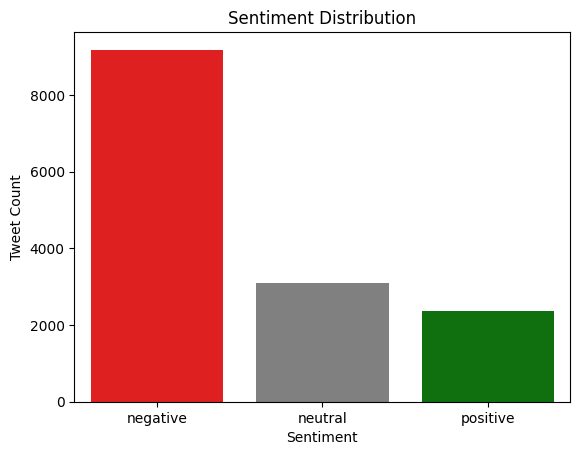

In [4]:
# Sentiment Distribution

sns.countplot(data=df, x='airline_sentiment', order=df['airline_sentiment'].value_counts().index,
              palette={'negative': 'red', 'neutral': 'gray', 'positive': 'green'})
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.show()

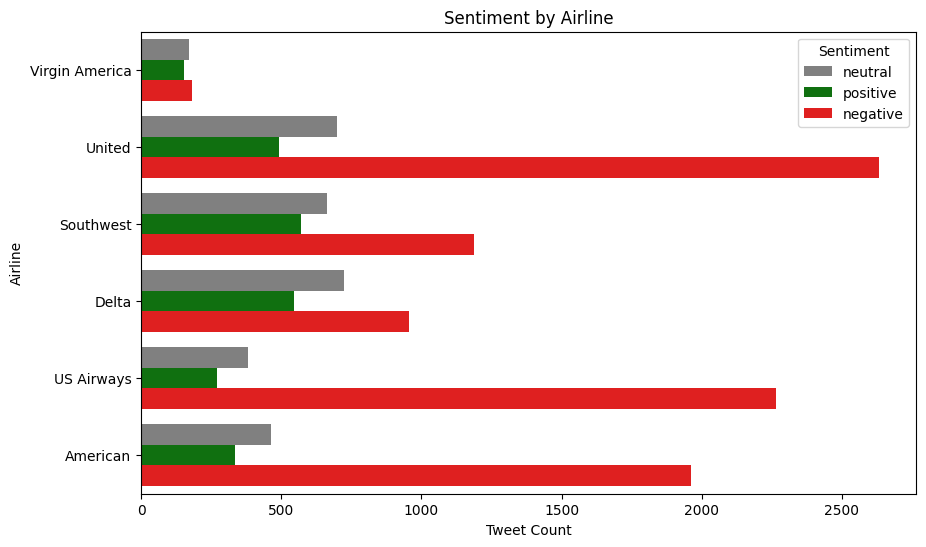

In [5]:
# Sentiment by Airline
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='airline', hue='airline_sentiment',
              palette={'negative': 'red', 'neutral': 'gray', 'positive': 'green'})
plt.title("Sentiment by Airline")
plt.xlabel("Tweet Count")
plt.ylabel("Airline")
plt.legend(title="Sentiment")
plt.show()

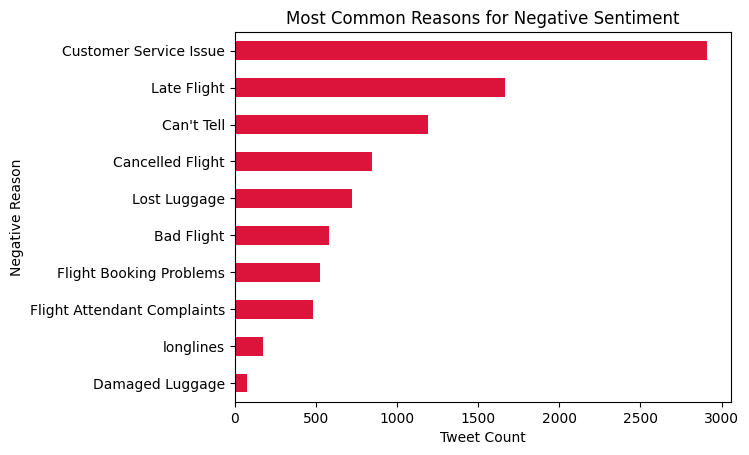

In [6]:
# Most Common Negative Reasons
df['negativereason'].value_counts().plot(kind='barh', color='crimson')
plt.title("Most Common Reasons for Negative Sentiment")
plt.xlabel("Tweet Count")
plt.ylabel("Negative Reason")
plt.gca().invert_yaxis()
plt.show()

In [7]:
# Tweet Location & Timezone Breakdown
print(df['tweet_location'].value_counts().head(10))
print(df['user_timezone'].value_counts().head(10))

tweet_location
Boston, MA           157
New York, NY         156
Washington, DC       150
New York             127
USA                  126
Chicago              104
Los Angeles, CA       96
New York City         96
NYC                   95
San Francisco, CA     91
Name: count, dtype: int64
user_timezone
Eastern Time (US & Canada)     3744
Central Time (US & Canada)     1931
Pacific Time (US & Canada)     1208
Quito                           738
Atlantic Time (Canada)          497
Mountain Time (US & Canada)     369
Arizona                         229
London                          195
Alaska                          108
Sydney                          107
Name: count, dtype: int64


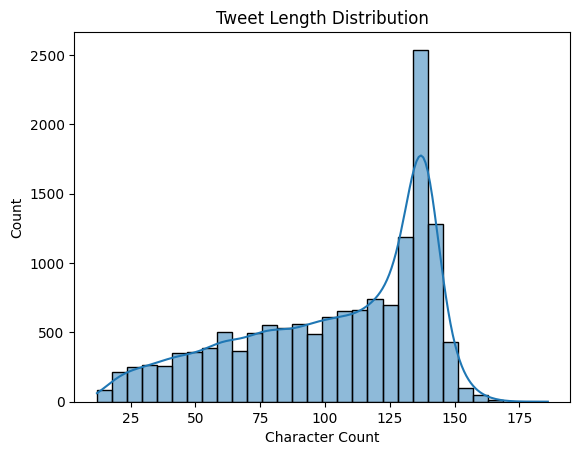

In [8]:
# Tweet Length Distribution
df['text_length'] = df['text'].astype(str).apply(len)
sns.histplot(data=df, x='text_length', bins=30, kde=True)
plt.title("Tweet Length Distribution")
plt.xlabel("Character Count")
plt.show()


C:\Users\Om Shete\AppData\Local\Temp\ipykernel_24736\1934814776.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='airline_sentiment', y='retweet_count',


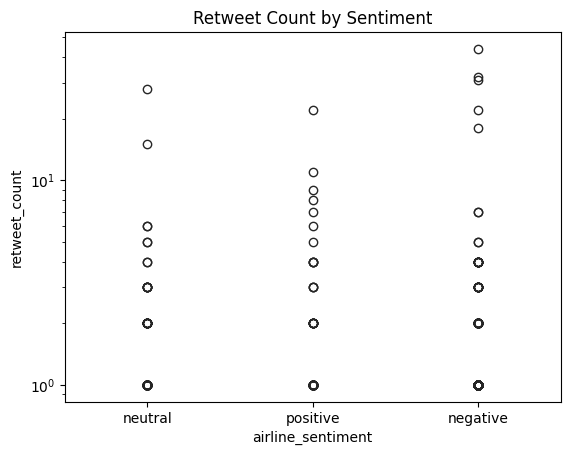

In [10]:
# Engagement Metrics: Retweet Analysis
sns.boxplot(data=df, x='airline_sentiment', y='retweet_count',
            palette={'negative': 'red', 'neutral': 'gray', 'positive': 'green'})
plt.title("Retweet Count by Sentiment")
plt.yscale('log')  # Log scale to handle outliers
plt.show()

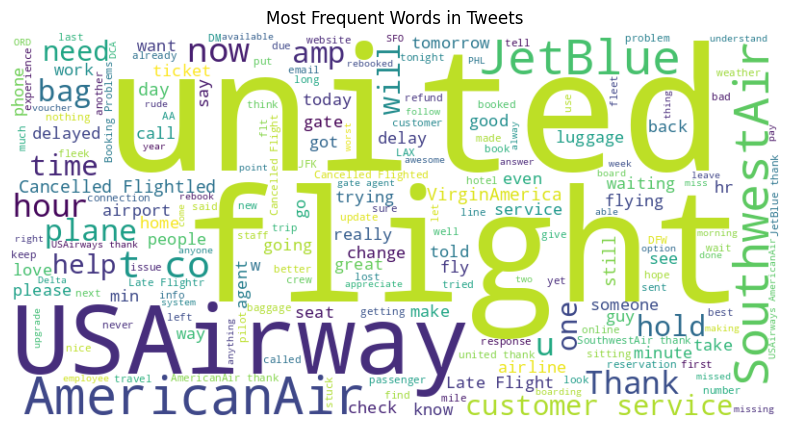

In [11]:
from wordcloud import WordCloud

text_combined = ' '.join(df['text'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Tweets")
plt.show()